# Monoid-165 Embedding Analysis

## Setup & Load

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from core.data import generate_mod_mult_dataset, get_device
from core.checkpoint import load_model, checkpoint_path, image_dir
from core.algebra import algebraic_jclass_order, jclass_permutation
from experiments.pca_fve import compute_pca_fve, plot_pca_fve
from experiments.embedding_fft import compute_fft_by_jclass, plot_fft_heatmaps, plot_fft_2d_frequency_reuse

In [2]:
P = 165
seed = 1
embed_dim = 128
mlp_dim = 512
n_heads = 4

device = torch.device("cpu")
print(f"P: {P}, device: {device}")

P: 165, device: cpu


In [3]:
ckpt = checkpoint_path("../experiments", P, embed_dim, n_heads, mlp_dim, seed)
model, checkpoint = load_model(ckpt, device)
print(f"Loaded: {ckpt}")

Loaded: ../experiments/P165_d128_h4_mlp512_s1.pt


## Analysis 1 — PCA on Embedding

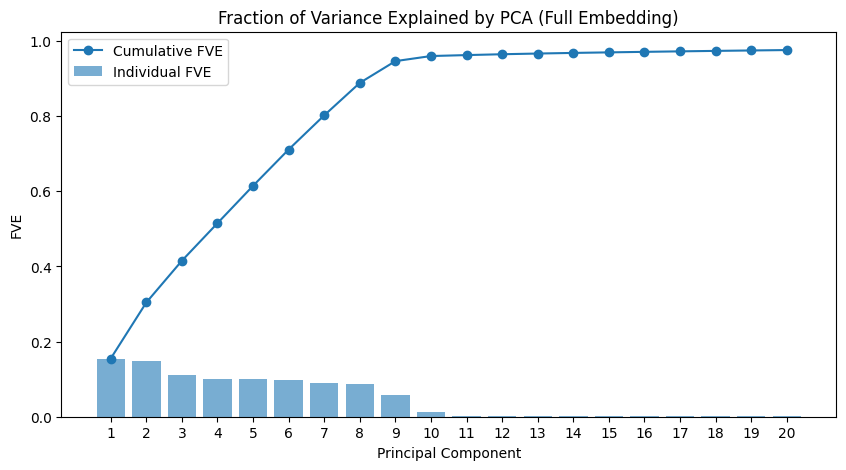

Components for 95% FVE: 10
Components for 99% FVE: 41


In [4]:
emb = model.embed.weight.detach()
emb_numpy = emb.cpu().numpy()[:-1]

pca_full = PCA()
pca_full.fit(emb_numpy)

fve = pca_full.explained_variance_ratio_
cum_fve = np.cumsum(fve)

num_components = min(20, len(fve))
plt.figure(figsize=(10, 5))
plt.bar(range(1, num_components + 1), fve[:num_components], alpha=0.6, label="Individual FVE")
plt.plot(range(1, num_components + 1), cum_fve[:num_components], marker="o", label="Cumulative FVE")
plt.title("Fraction of Variance Explained by PCA (Full Embedding)")
plt.xlabel("Principal Component")
plt.ylabel("FVE")
plt.xticks(range(1, num_components + 1))
plt.legend()
plt.show()

print(f"Components for 95% FVE: {np.argmax(cum_fve >= 0.95) + 1}")
print(f"Components for 99% FVE: {np.argmax(cum_fve >= 0.99) + 1}")

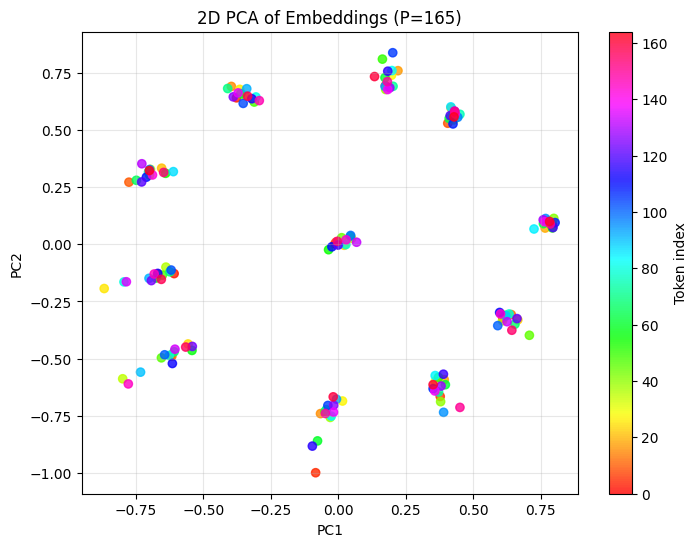

In [5]:
proj = pca_full.transform(emb_numpy)[:, :2]
colors = np.arange(proj.shape[0])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(proj[:, 0], proj[:, 1], c=colors, cmap="hsv", alpha=0.8)
plt.colorbar(scatter, label="Token index")
plt.title(f"2D PCA of Embeddings (P={P})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
proj_3d = pca_full.transform(emb_numpy)[:, :3]
elements = np.arange(P)
j_classes = np.gcd(elements, P)
j_class_labels = [f"J-class: {d}" for d in j_classes]

import plotly.express as px
fig = px.scatter_3d(
    x=proj_3d[:, 0], y=proj_3d[:, 1], z=proj_3d[:, 2],
    color=j_class_labels,
    title=f"3D PCA of Token Embeddings by J-class (Modulo {P})"
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.show()

Number of elements in J1: 80


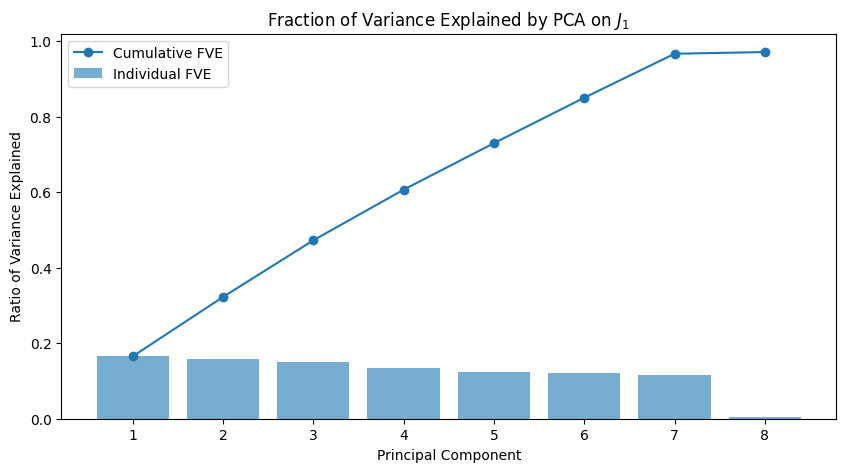

Components for 95% FVE on J1: 7


In [7]:
j_classes = np.gcd(elements, P)
j1_mask = (j_classes == 1)
emb_j1 = emb_numpy[j1_mask]

print(f"Number of elements in J1: {j1_mask.sum()}")

pca_j1 = PCA()
pca_j1.fit(emb_j1)
fve_j1 = pca_j1.explained_variance_ratio_
cum_fve_j1 = np.cumsum(fve_j1)

num_components = min(8, len(fve_j1))
plt.figure(figsize=(10, 5))
plt.bar(range(1, num_components + 1), fve_j1[:num_components], alpha=0.6, label="Individual FVE")
plt.plot(range(1, num_components + 1), cum_fve_j1[:num_components], marker="o", label="Cumulative FVE")
plt.title(r"Fraction of Variance Explained by PCA on $J_1$")
plt.xlabel("Principal Component")
plt.ylabel("Ratio of Variance Explained")
plt.xticks(range(1, num_components + 1))
plt.legend()
plt.show()

print(f"Components for 95% FVE on J1: {np.argmax(cum_fve_j1 >= 0.95) + 1}")


PCA FVE Report
   J-class   Size   Actual  Random mean   Random std
----------------------------------------------------
  J_1          80        7         9.51         0.50
  J_3          40        6         9.27         0.45
  J_5          20        5         8.43         0.51
  J_11          8        3         5.49         0.50
  J_15         10        5         6.40         0.52
  J_33          4        2         2.99         0.09
  J_55          2        1         1.00         0.00
  J_165         1        0         0.00         0.00


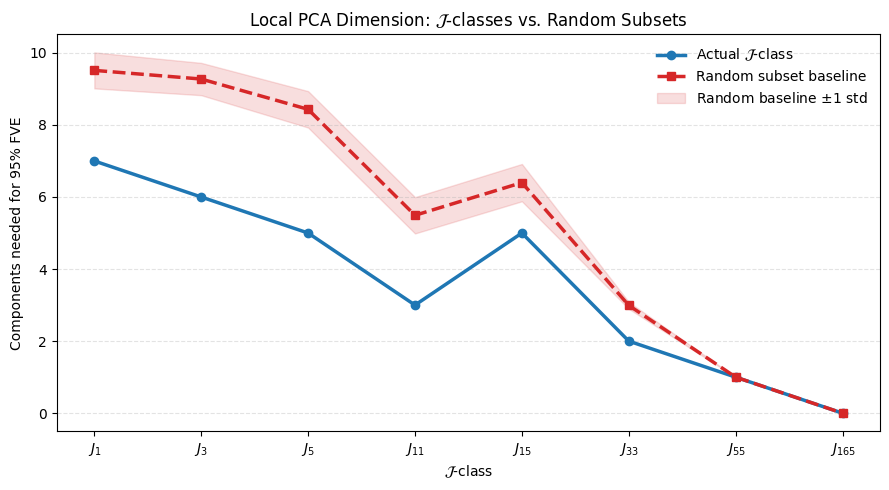

In [8]:
# Figure 2: PCA FVE J-class vs random baseline — uses our library
results = compute_pca_fve(model, P, threshold=0.95, n_random=1000)
plot_pca_fve(results, P)
plt.show()

## Analysis 2 — Discrete FFT of Embedding

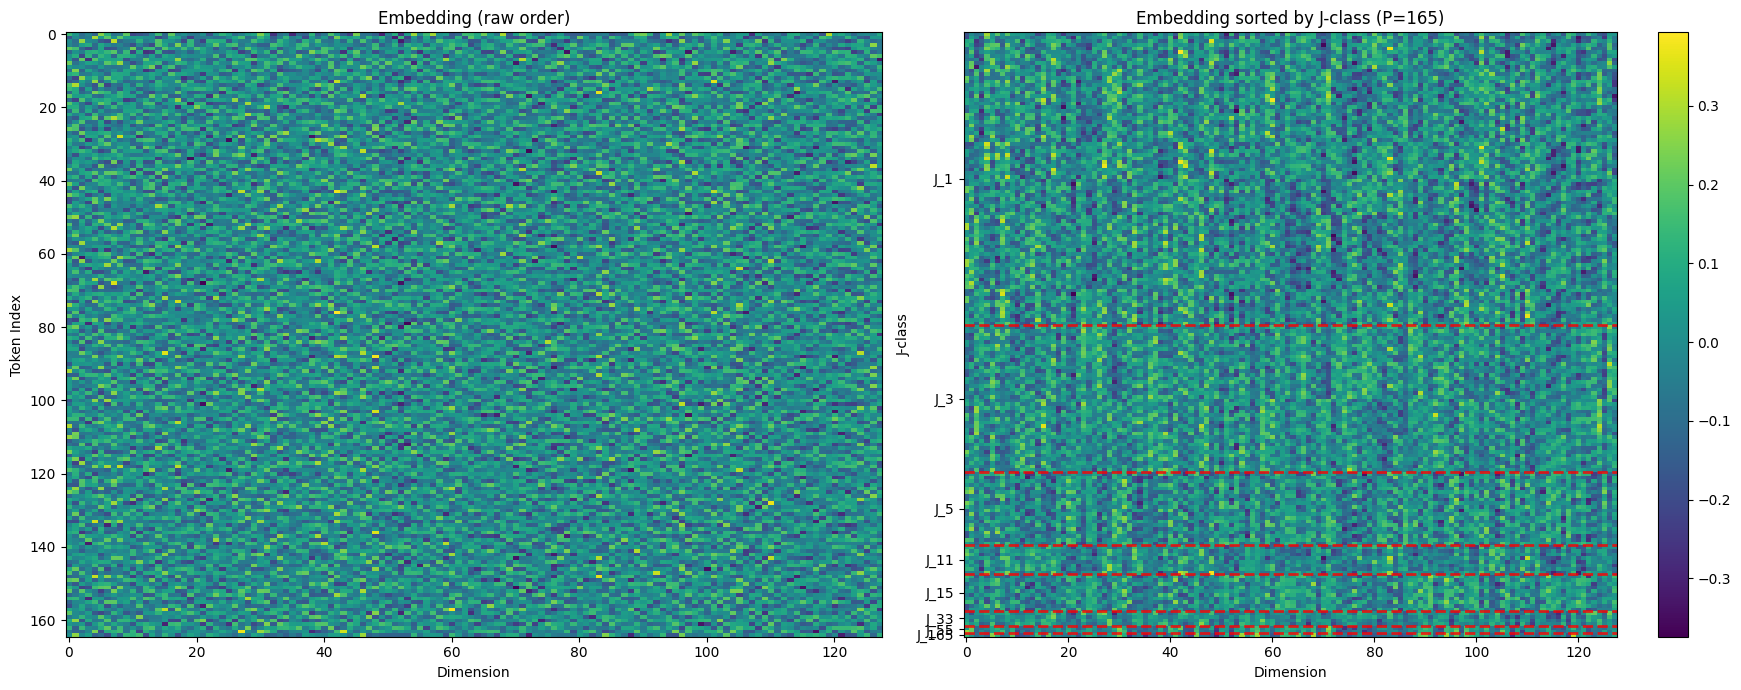

In [9]:
perm = algebraic_jclass_order(P)
emb_sorted = emb_numpy[perm["sorted_indices"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.imshow(emb_numpy, aspect="auto")
ax1.set(title="Embedding (raw order)", xlabel="Dimension", ylabel="Token Index")

im = ax2.imshow(emb_sorted, aspect="auto", cmap="viridis")
for b in perm["boundaries"]:
    ax2.axhline(b - 0.5, color="red", linewidth=2, linestyle="--", alpha=0.8)
ax2.set_yticks(perm["tick_positions"])
ax2.set_yticklabels(perm["tick_labels"])
ax2.set(title=f"Embedding sorted by J-class (P={P})", xlabel="Dimension", ylabel="J-class")
plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.show()

/Users/hemkeshb/users/trmnl/worktrees/addingcolabs-20260423-150257/experiments/embedding_fft.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


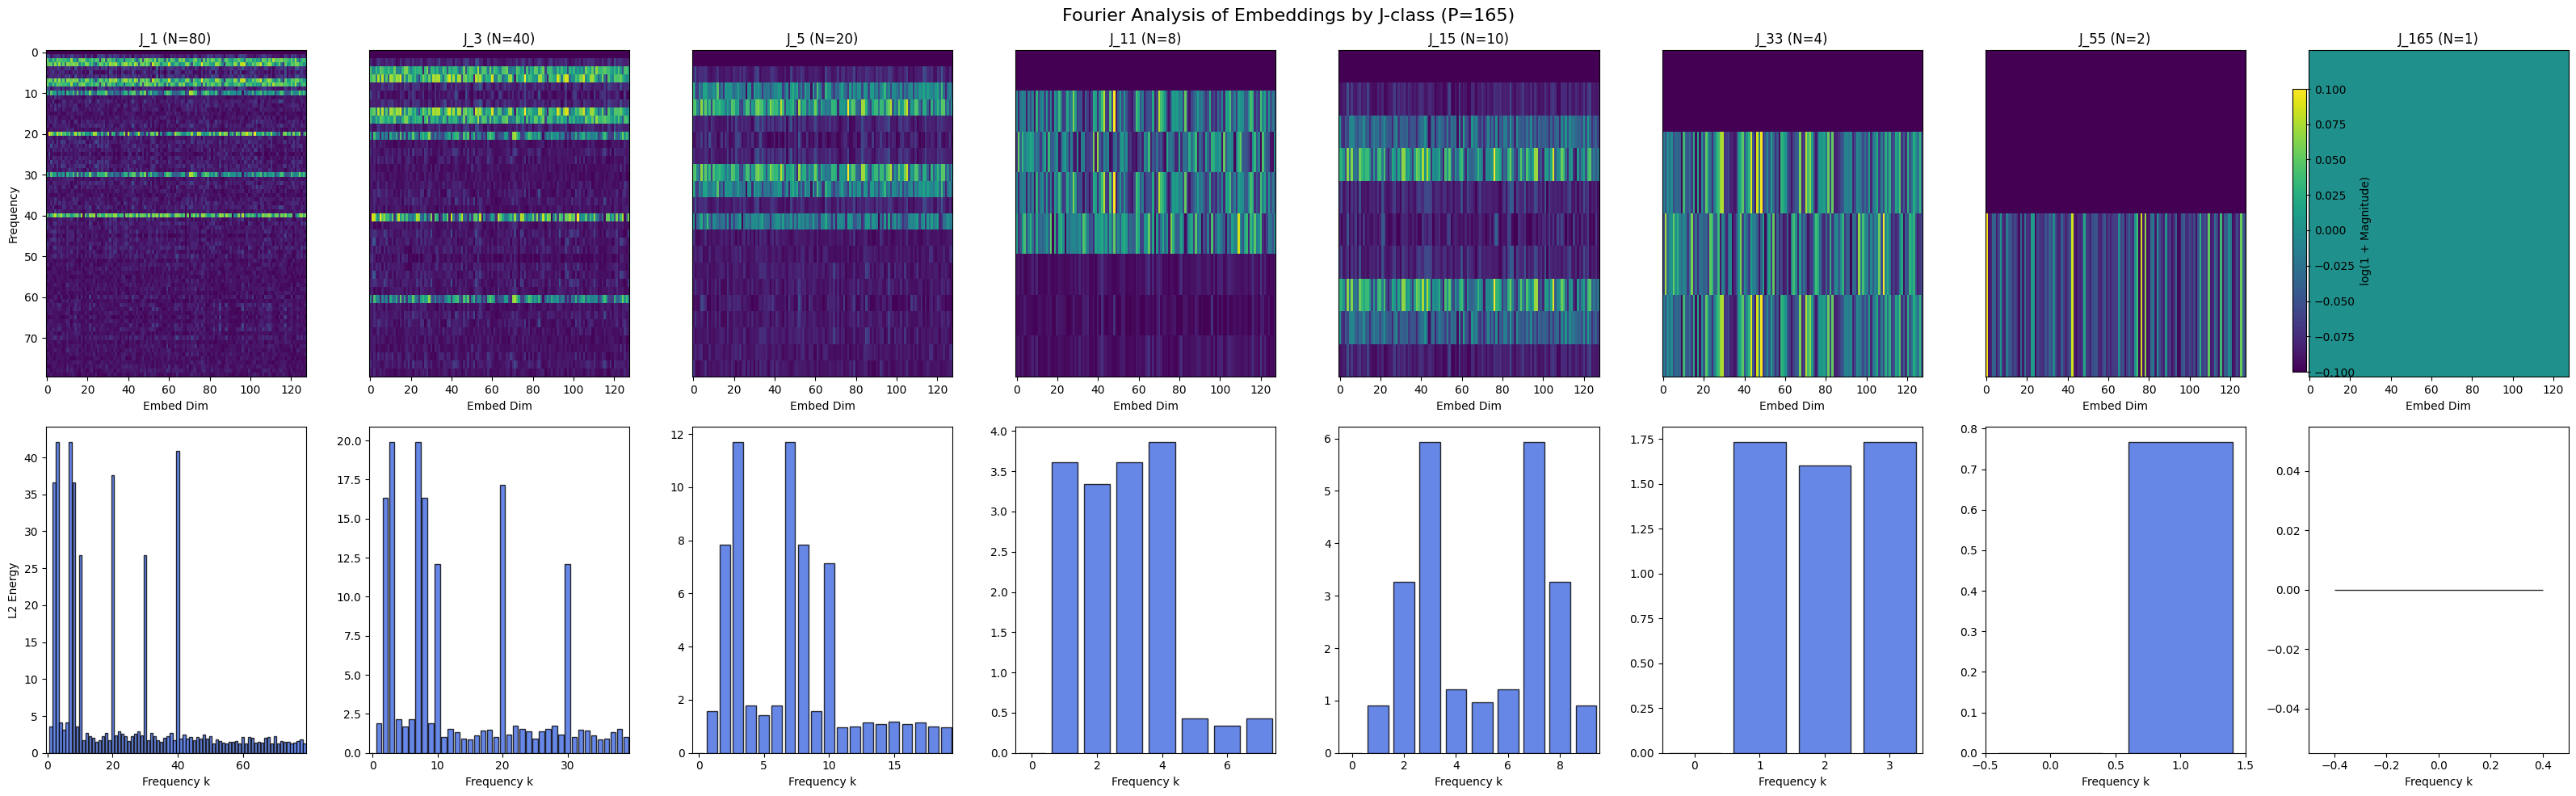

In [10]:
fft_results, perm = compute_fft_by_jclass(model, P)
plot_fft_heatmaps(fft_results, P)
plt.show()

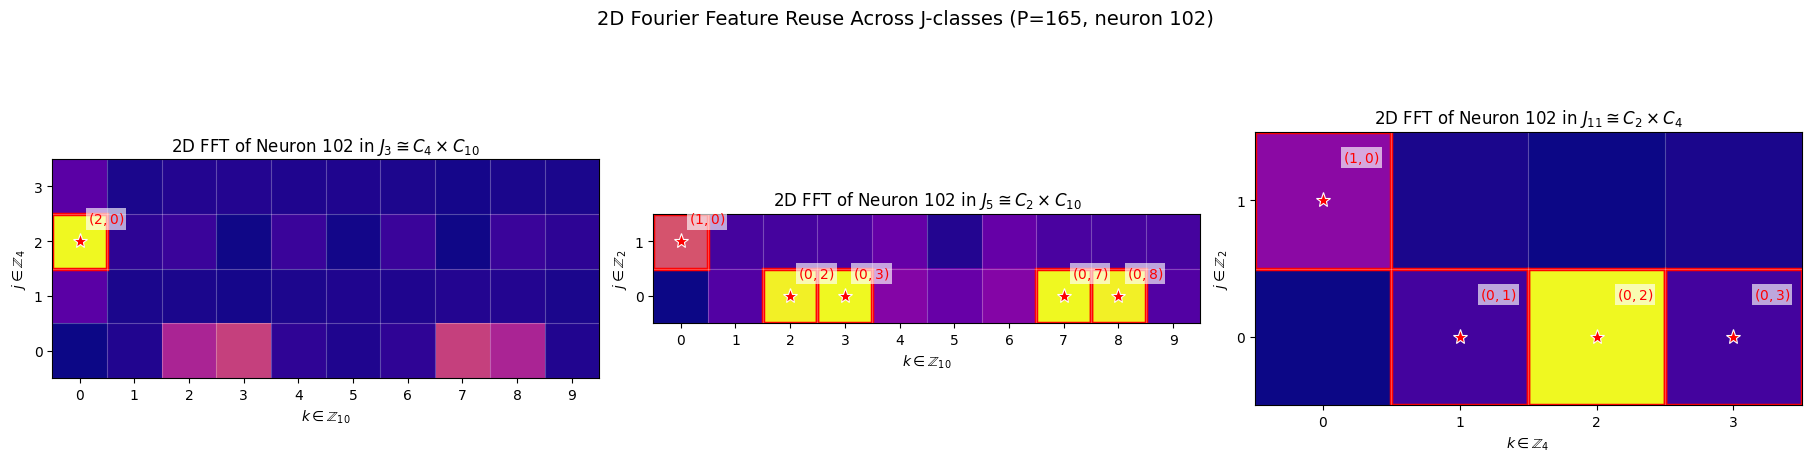

In [11]:
plot_fft_2d_frequency_reuse(fft_results, P)
plt.show()

In [12]:
from experiments.fve import compute_fve, print_fve_report

# Table 2
K_MAP = {1: 8, 3: 7, 5: 5, 11: 4, 15: 4, 33: 3, 55: 1}

fve_results = compute_fve(model, P, k_map=K_MAP)
print_fve_report(fve_results, P)

J-class   | |J|   | Freqs (K/Total) | SEC (Top K)  | Baseline   | Enrichment
--------------------------------------------------------------------------------
J_1       | 80    | 8 / 79          | 97.0%        | 10.1%      | 9.6x
J_3       | 40    | 7 / 39          | 96.8%        | 17.9%      | 5.4x
J_5       | 20    | 5 / 19          | 95.0%        | 26.3%      | 3.6x
J_11      | 8     | 4 / 7           | 99.1%        | 57.1%      | 1.7x
J_15      | 10    | 4 / 9           | 94.3%        | 44.4%      | 2.1x
J_33      | 4     | 3 / 3           | 100.0%        | 100.0%      | 1.0x
J_55      | 2     | 1 / 1           | 100.0%        | 100.0%      | 1.0x
J_165     | 1     | N/A             | N/A          | N/A        | N/A

Top Frequencies for J_1:
  Coord: (np.int64(0), np.int64(0), np.int64(7))
  Coord: (np.int64(0), np.int64(0), np.int64(3))
  Coord: (np.int64(1), np.int64(0), np.int64(0))
  Coord: (np.int64(0), np.int64(2), np.int64(0))
  Coord: (np.int64(0), np.int64(0), np.int64(8))


## Misc

In [13]:
for i in range(P):
    if (i ** 2 % P == i):
        print(f"{i} (J-class: J_{np.gcd(i, P)})")

0 (J-class: J_165)
1 (J-class: J_1)
45 (J-class: J_15)
55 (J-class: J_55)
66 (J-class: J_33)
100 (J-class: J_5)
111 (J-class: J_3)
121 (J-class: J_11)
